### **Router**

In [31]:
from dotenv import load_dotenv
import os 
load_dotenv()

if os.environ["GOOGLE_API_KEY"]:
    print("True")
else:
    print("False")

True


In [32]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature = 0)

In [33]:
### Graph Schema

from pydantic import BaseModel,Field
from typing import Literal

class llm_schema(BaseModel):
    category:Literal["insta","twitter","linkedin"] = Field(description="This topic for which to generate the post")
    topic:str = Field(description="Topic of the post to generate")


In [34]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [35]:
llm_with_schema.invoke("I want to generate the twitter post about AI")

llm_schema(category='twitter', topic='AI')

In [36]:
from typing import TypedDict,List

class graph_schema(TypedDict):
    input : str
    topic : str
    post : str

In [60]:
def decider_node(state:graph_schema)->graph_schema:
    user_input = state["input"]
    category = llm_schema.invoke(user_input).category
    state["category"] = category
    topic = category.topic
    return state

def create_insta(state:graph_schema)->graph_schema:
    topic = state["topic"]
    post = llm.invoke("what is insta post about{topic}").content
    state["post"] = post
    return {"post":post}

def create_twitter(state:graph_schema)->graph_schema:
    topic = state["topic"]
    post = llm.invoke("what is twitter post about{topic}").content
    state["post"] = post
    return {"post":post}

def create_linkedin(state:graph_schema)->graph_schema:
    topic = state["topic"]
    post = llm.invoke("what is linkedin post about{topic}").content
    state["post"] = post
    return {"post":post}

In [61]:
def condition_node(state:graph_schema)->str:
    category = state["category"]

    if category == "insta":
        return "create_insta"
    elif category == "twitter":
        return "create_twitter"
    elif category == "linkedin":
        return "create_linkedin"
    else:
        ValueError("Invalid category")


In [62]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)
graph.add_node("decider_node",decider_node)
graph.add_node("create_insta",create_insta)
graph.add_node("create_twitter",create_twitter)
graph.add_node("create_linkedin",create_linkedin)

graph.add_edge(START,"decider_node")
graph.add_conditional_edges("decider_node",condition_node)
graph.add_edge("decider_node","create_insta")
graph.add_edge("decider_node","create_twitter")
graph.add_edge("decider_node","create_linkedin")
graph.add_edge("create_insta",END)
graph.add_edge("create_twitter",END)
graph.add_edge("create_linkedin",END)

router_graph = graph.compile()

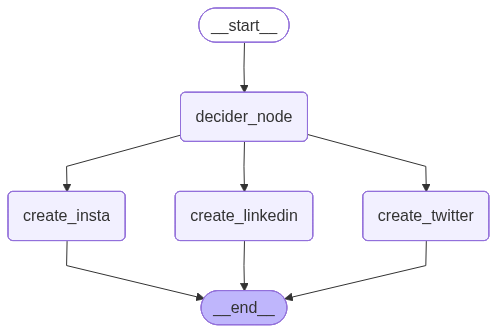

In [63]:
from IPython.display import display,Image

Image(router_graph.get_graph().draw_mermaid_png())